# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/srvnkumr27/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [12]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Hugging Face token
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.getenv("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN not found. Add HF_TOKEN to Colab Secrets."
    )

# DuckDB
con = duckdb.connect()

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

# Same dataset and month as W03
DATASET_URL = "hf://datasets/FlyRank/internship-warehouse"

MID_PANEL_PATH = (
    f"{DATASET_URL}/fact_content_daily_performance/"
    f"month=2026-03/*.parquet"
)

print("DuckDB initialized successfully.")

DuckDB initialized successfully.


In [13]:
query_build_feature_vector = f"""
WITH daily_data AS (

    SELECT
        client_hash_id,
        content_hash_id,
        CAST(report_date AS DATE) AS report_date,

        gsc_clicks,
        gsc_impressions,
        gsc_avg_position,

        gsc_data_available,

        -- Target: clicks on next day
        LEAD(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
        ) AS target_next_day_clicks,

        -- Intentional leakage trap
        LEAD(gsc_impressions) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
        ) AS trap_next_day_impressions

    FROM read_parquet('{MID_PANEL_PATH}')

    WHERE gsc_data_available IS TRUE
),

feature_vector AS (

    SELECT
        client_hash_id,
        content_hash_id,
        report_date,

        -- Feature 1
        AVG(gsc_clicks) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS clicks_7d_avg,

        -- Feature 2
        AVG(gsc_impressions) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS impressions_7d_avg,

        -- Feature 3
        AVG(gsc_avg_position) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY report_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS position_7d_avg,

        -- Feature 4
        (
            SUM(gsc_clicks) OVER (
                PARTITION BY client_hash_id, content_hash_id
                ORDER BY report_date
                ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
            ) * 1.0
            /
            NULLIF(
                SUM(gsc_impressions) OVER (
                    PARTITION BY client_hash_id, content_hash_id
                    ORDER BY report_date
                    ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
                ),
                0
            )
        ) AS ctr_7d,

        -- Feature 5
        CASE
            WHEN DAYOFWEEK(report_date) IN (0, 6)
            THEN 1
            ELSE 0
        END AS is_weekend,

        -- Leakage trap
        trap_next_day_impressions,

        -- Label
        target_next_day_clicks

    FROM daily_data
)

SELECT *
FROM feature_vector

WHERE target_next_day_clicks IS NOT NULL
  AND trap_next_day_impressions IS NOT NULL

LIMIT 100000
"""

df_vector = con.sql(
    query_build_feature_vector
).df()

# Missing-value handling
df_vector["clicks_7d_avg"] = (
    df_vector["clicks_7d_avg"]
    .fillna(0.0)
)

df_vector["impressions_7d_avg"] = (
    df_vector["impressions_7d_avg"]
    .fillna(0.0)
)

df_vector["position_7d_avg"] = (
    df_vector["position_7d_avg"]
    .fillna(100.0)
)

df_vector["ctr_7d"] = (
    df_vector["ctr_7d"]
    .fillna(0.0)
)

df_vector["is_weekend"] = (
    df_vector["is_weekend"]
    .astype(int)
)

print(
    "Feature vector created successfully:",
    df_vector.shape
)

display(df_vector.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature vector created successfully: (100000, 10)


,client_hash_id,content_hash_id,report_date,clicks_7d_avg,impressions_7d_avg,position_7d_avg,ctr_7d,is_weekend,trap_next_day_impressions,target_next_day_clicks
0,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,2026-03-01,0.00,28.000000,11.178571,0.000000,1,19,0
1,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,2026-03-02,0.00,23.500000,11.273496,0.000000,0,35,0
2,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,2026-03-03,0.00,27.333333,12.287093,0.000000,0,33,1
3,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,2026-03-04,0.25,28.750000,12.268350,0.008696,0,37,1
4,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,2026-03-05,0.40,30.400000,12.198464,0.013158,0,23,0


In [14]:
features = [
    "clicks_7d_avg",
    "impressions_7d_avg",
    "position_7d_avg",
    "ctr_7d",
    "is_weekend"
]

target = "target_next_day_clicks"

print("Safe features:")
for feature in features:
    print("-", feature)

print("\nTarget:")
print("-", target)

Safe features:
- clicks_7d_avg
- impressions_7d_avg
- position_7d_avg
- ctr_7d
- is_weekend

Target:
- target_next_day_clicks


=== Feature Distributions ===


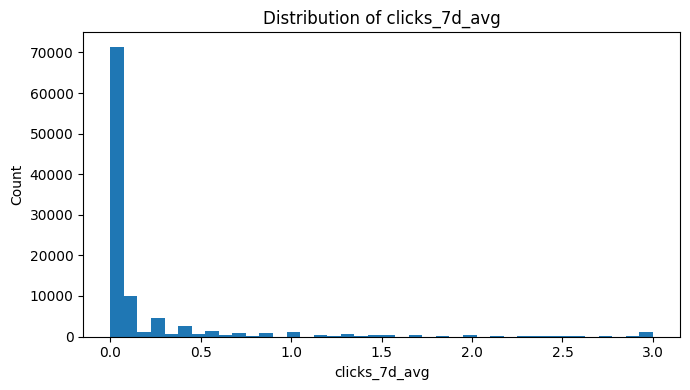

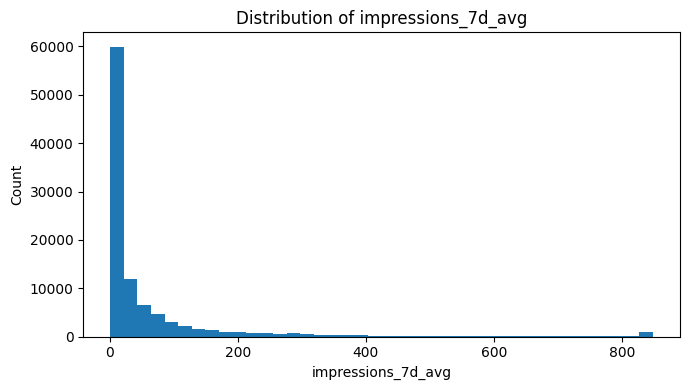

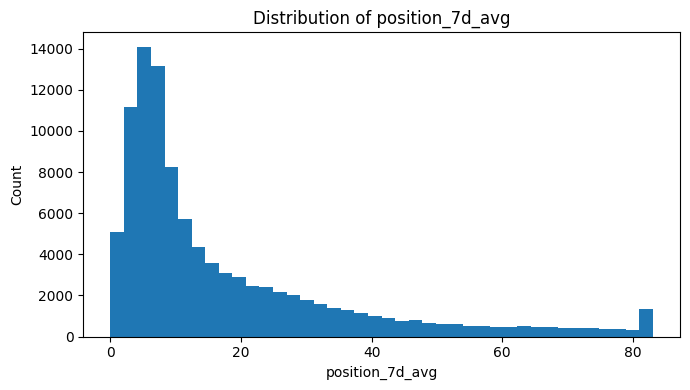

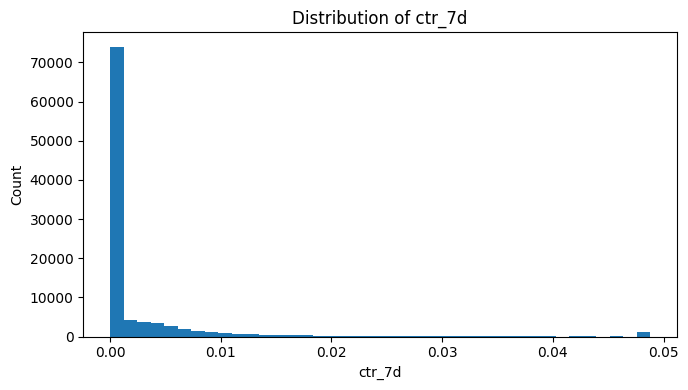

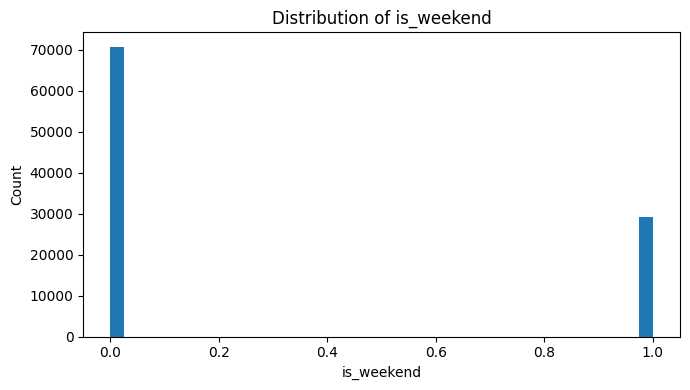

In [15]:
print("=== Feature Distributions ===")

for col in features:

    plt.figure(figsize=(7, 4))

    data = df_vector[col].dropna()

    # Clip extreme values only for visualization
    upper = data.quantile(0.99)

    plt.hist(
        data.clip(upper=upper),
        bins=40
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

In [16]:
quality = pd.DataFrame({
    "missing": df_vector[features].isna().sum(),

    "missing_pct": (
        df_vector[features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    "unique_values": (
        df_vector[features]
        .nunique()
    )
})

display(quality)

,missing,missing_pct,unique_values
clicks_7d_avg,0,0.0,245
impressions_7d_avg,0,0.0,7032
position_7d_avg,0,0.0,82219
ctr_7d,0,0.0,8661
is_weekend,0,0.0,2


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*


--- Signal Test #1: Impressions vs Next-Day Clicks ---
Pearson Correlation: 0.809


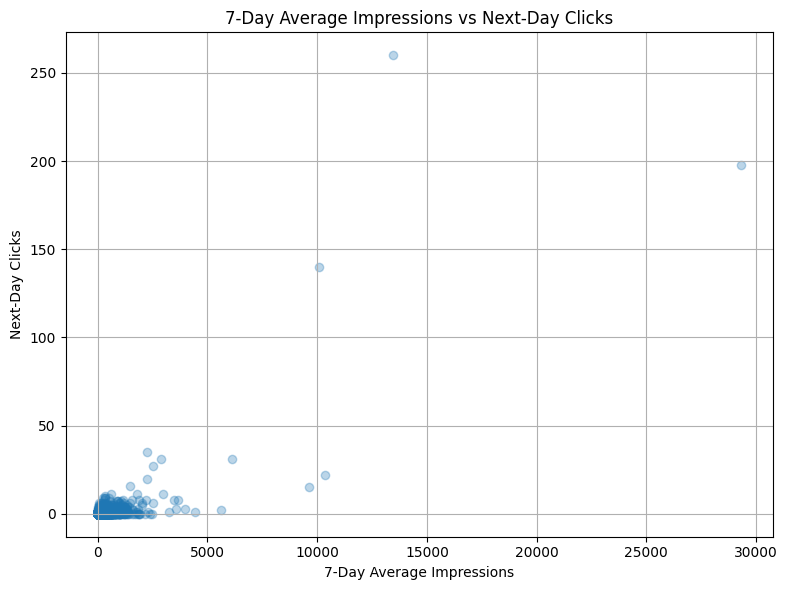

Verdict: CONFIRMED
Interpretation: Higher historical visibility should generally provide more opportunity for future clicks.


In [17]:
print("\n--- Signal Test #1: Impressions vs Next-Day Clicks ---")

x = df_vector["impressions_7d_avg"]
y = df_vector["target_next_day_clicks"]

correlation = x.corr(
    y,
    method="pearson"
)

print(
    f"Pearson Correlation: {correlation:.3f}"
)

plt.figure(figsize=(8, 6))

sample = df_vector.sample(
    min(10000, len(df_vector)),
    random_state=42
)

plt.scatter(
    sample["impressions_7d_avg"],
    sample["target_next_day_clicks"],
    alpha=0.3
)

plt.xlabel(
    "7-Day Average Impressions"
)

plt.ylabel(
    "Next-Day Clicks"
)

plt.title(
    "7-Day Average Impressions vs Next-Day Clicks"
)

plt.grid(True)
plt.tight_layout()
plt.show()

if correlation >= 0.7:
    verdict = "CONFIRMED"
elif correlation <= -0.3:
    verdict = "OPPOSITE"
elif abs(correlation) >= 0.3:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")

print(
    "Interpretation: Higher historical visibility "
    "should generally provide more opportunity for future clicks."
)


--- Signal Test #2: Average Position vs CTR ---
Pearson Correlation: -0.067


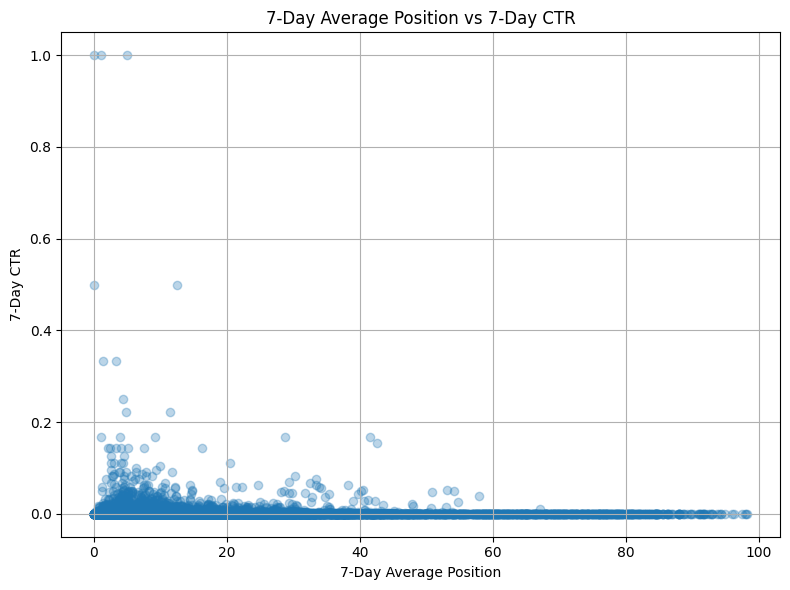

Verdict: FALSE
Interpretation: Better ranking means a lower position number, so a negative relationship with CTR is expected.


In [18]:
print("\n--- Signal Test #2: Average Position vs CTR ---")

correlation = df_vector[
    "position_7d_avg"
].corr(
    df_vector["ctr_7d"],
    method="pearson"
)

print(
    f"Pearson Correlation: {correlation:.3f}"
)

plt.figure(figsize=(8, 6))

sample = df_vector.sample(
    min(10000, len(df_vector)),
    random_state=42
)

plt.scatter(
    sample["position_7d_avg"],
    sample["ctr_7d"],
    alpha=0.3
)

plt.xlabel(
    "7-Day Average Position"
)

plt.ylabel(
    "7-Day CTR"
)

plt.title(
    "7-Day Average Position vs 7-Day CTR"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# Lower position number = better ranking.
# Therefore negative correlation is expected.

if correlation <= -0.7:
    verdict = "CONFIRMED"
elif correlation >= 0.3:
    verdict = "OPPOSITE"
elif abs(correlation) >= 0.2:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")

print(
    "Interpretation: Better ranking means a lower "
    "position number, so a negative relationship with "
    "CTR is expected."
)


--- Signal Test #3: Historical Clicks vs Next-Day Clicks ---
Pearson Correlation: 0.953


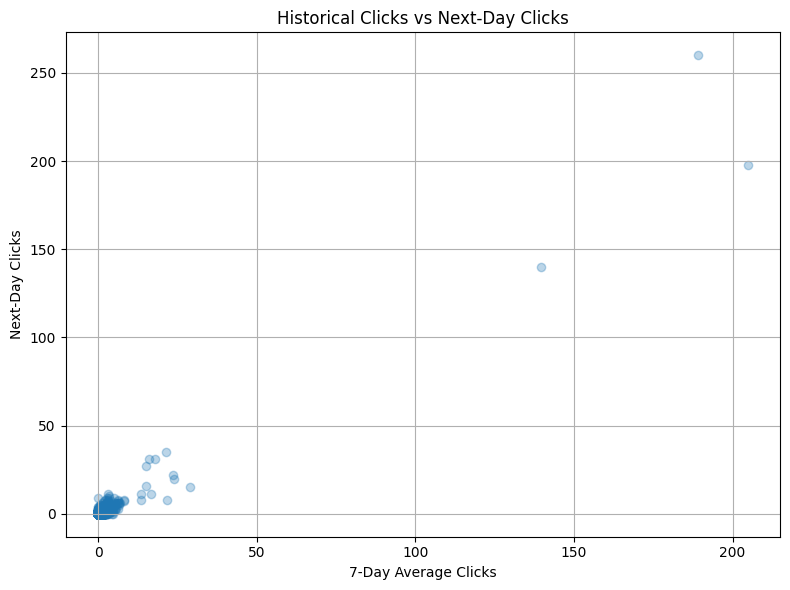

Verdict: CONFIRMED
Interpretation: Recent historical clicks provide a reasonable test of whether past traffic contains predictive signal for next-day clicks.


In [19]:
print(
    "\n--- Signal Test #3: Historical Clicks vs Next-Day Clicks ---"
)

correlation = df_vector[
    "clicks_7d_avg"
].corr(
    df_vector["target_next_day_clicks"],
    method="pearson"
)

print(
    f"Pearson Correlation: {correlation:.3f}"
)

plt.figure(figsize=(8, 6))

sample = df_vector.sample(
    min(10000, len(df_vector)),
    random_state=42
)

plt.scatter(
    sample["clicks_7d_avg"],
    sample["target_next_day_clicks"],
    alpha=0.3
)

plt.xlabel(
    "7-Day Average Clicks"
)

plt.ylabel(
    "Next-Day Clicks"
)

plt.title(
    "Historical Clicks vs Next-Day Clicks"
)

plt.grid(True)
plt.tight_layout()
plt.show()

if correlation >= 0.7:
    verdict = "CONFIRMED"
elif correlation <= -0.3:
    verdict = "OPPOSITE"
elif abs(correlation) >= 0.3:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")

print(
    "Interpretation: Recent historical clicks "
    "provide a reasonable test of whether past traffic "
    "contains predictive signal for next-day clicks."
)

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [20]:
print(
    "\n--- Flag-Linked Test: CTR Improvement Flag ---"
)

df_flag = df_vector.copy()

def position_bucket(position):

    if position <= 3:
        return "1-3"

    elif position <= 6:
        return "4-6"

    elif position <= 10:
        return "7-10"

    elif position <= 20:
        return "11-20"

    elif position > 20:
        return ">20"

    else:
        return "Other"


df_flag["position_bucket"] = (
    df_flag["position_7d_avg"]
    .apply(position_bucket)
)

bucket_summary = (
    df_flag
    .groupby("position_bucket")
    .agg(
        mean_ctr=("ctr_7d", "mean"),
        mean_impressions=(
            "impressions_7d_avg",
            "mean"
        ),
        row_count=("ctr_7d", "size")
    )
)

bucket_order = [
    "1-3",
    "4-6",
    "7-10",
    "11-20",
    ">20",
    "Other"
]

bucket_summary = (
    bucket_summary
    .reindex(bucket_order)
)

display(bucket_summary)


--- Flag-Linked Test: CTR Improvement Flag ---


,mean_ctr,mean_impressions,row_count
position_bucket,,,
1-3,0.004697,132.490813,9526.0
4-6,0.005054,92.240743,19359.0
7-10,0.003755,49.637596,21574.0
11-20,0.003067,64.441693,19877.0
>20,0.001502,63.460794,29664.0
Other,NaN,NaN,NaN


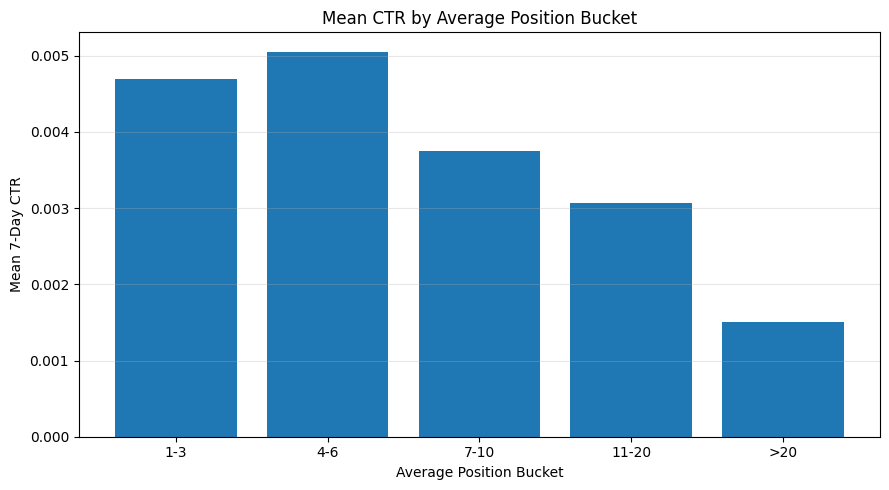

In [21]:
plt.figure(figsize=(9, 5))

plt.bar(
    bucket_summary.index,
    bucket_summary["mean_ctr"]
)

plt.xlabel(
    "Average Position Bucket"
)

plt.ylabel(
    "Mean 7-Day CTR"
)

plt.title(
    "Mean CTR by Average Position Bucket"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [22]:
impression_threshold = (
    df_flag["impressions_7d_avg"]
    .quantile(0.75)
)

ctr_threshold = (
    df_flag["ctr_7d"]
    .quantile(0.25)
)

flag_candidates = df_flag[
    (
        df_flag["impressions_7d_avg"]
        >= impression_threshold
    )
    &
    (
        df_flag["ctr_7d"]
        <= ctr_threshold
    )
].copy()

print(
    "High-visibility / low-CTR candidates:",
    len(flag_candidates)
)

display(
    flag_candidates[
        [
            "client_hash_id",
            "content_hash_id",
            "report_date",
            "impressions_7d_avg",
            "ctr_7d",
            "position_7d_avg"
        ]
    ].head(20)
)

High-visibility / low-CTR candidates: 7397


,client_hash_id,content_hash_id,report_date,impressions_7d_avg,ctr_7d,position_7d_avg
104,client_08a6a72ff48e62c0,content_0129e58900e5ec36,2026-03-03,66.333333,0.0,13.558854
105,client_08a6a72ff48e62c0,content_0129e58900e5ec36,2026-03-04,55.000000,0.0,13.419140
107,client_08a6a72ff48e62c0,content_0129e58900e5ec36,2026-03-06,53.500000,0.0,12.325003
487,client_08a6a72ff48e62c0,content_0a1bc85d6efb188e,2026-03-23,53.142857,0.0,13.489533
489,client_08a6a72ff48e62c0,content_0a1bc85d6efb188e,2026-03-25,52.714286,0.0,13.033351
490,client_08a6a72ff48e62c0,content_0a1bc85d6efb188e,2026-03-26,56.428571,0.0,12.855602
491,client_08a6a72ff48e62c0,content_0a1bc85d6efb188e,2026-03-27,55.285714,0.0,12.697958
492,client_08a6a72ff48e62c0,content_0a1bc85d6efb188e,2026-03-28,52.428571,0.0,12.233394
556,client_08a6a72ff48e62c0,content_0c3846c1628bd5a2,2026-03-23,54.428571,0.0,7.677070
557,client_08a6a72ff48e62c0,content_0c3846c1628bd5a2,2026-03-24,55.714286,0.0,8.426243


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The Flag-Linked Test: CTR Improvement Flag
Flag Assumption: Pages with strong visibility (high impressions) but relatively low CTR are good candidates for title and meta description optimization.

Mini Test: Group pages by average search position and calculate the mean CTR for each bucket.

In [23]:
safe_features = [
    "clicks_7d_avg",
    "impressions_7d_avg",
    "position_7d_avg",
    "ctr_7d",
    "is_weekend"
]

for feature in safe_features:
    assert feature in df_vector.columns

assert "target_next_day_clicks" in df_vector.columns
assert "trap_next_day_impressions" in df_vector.columns

print("✓ All five contract features exist.")
print("✓ Target exists.")
print("✓ Leakage trap exists for audit.")
print("✓ Leakage trap is NOT included in safe_features.")

✓ All five contract features exist.
✓ Target exists.
✓ Leakage trap exists for audit.
✓ Leakage trap is NOT included in safe_features.


In [24]:
print("Safe feature set:")
print(safe_features)

print("\nExcluded leakage field:")
print("trap_next_day_impressions")

print("\nTarget:")
print("target_next_day_clicks")

Safe feature set:
['clicks_7d_avg', 'impressions_7d_avg', 'position_7d_avg', 'ctr_7d', 'is_weekend']

Excluded leakage field:
trap_next_day_impressions

Target:
target_next_day_clicks


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.